In [1]:
# ============================================================
# [공통 임포트] - 모든 섹션 실행 전 반드시 먼저 실행
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (accuracy_score, confusion_matrix,
                               silhouette_score, roc_curve, auc)

iris_data = load_iris()
print("Import complete")

Import complete


diff:      [-0.41  3.41 -0.13  1.58  0.41  0.99  1.91  1.53  2.02  1.07]
mean_diff: 1.238
sd_diff:   1.122772
t_stat:    3.486815


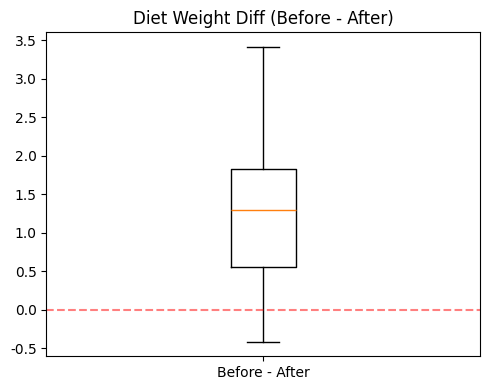


[Two-sided test] t=3.4868, p=0.0069
Result: Reject H0 (Significant difference) (alpha=0.05)


In [2]:
# ============================================================
# SECTION 1. 가설 설정 및 검정 (쌍체 t-검정)
# ============================================================
# 데이터: diet.csv (다이어트 프로그램 전후 체중 - PDF 표 1-1 원문)
# 목적: 다이어트 프로그램의 체중 감소 효과를 통계적으로 검증

# PDF 표 1-1 원문 데이터
Before = np.array([57.90, 64.68, 66.30, 59.97, 74.12, 72.71, 72.50, 68.36, 78.86, 49.24])
After  = np.array([58.31, 61.27, 66.43, 58.39, 73.71, 71.72, 70.59, 66.83, 76.84, 48.17])

diff      = Before - After
mean_diff = np.mean(diff)
sd_diff   = np.std(diff, ddof=1)
t_stat    = mean_diff / (sd_diff / np.sqrt(len(diff)))

print(f"diff:      {np.round(diff, 2)}")
print(f"mean_diff: {mean_diff:.3f}")    # 1.238
print(f"sd_diff:   {sd_diff:.6f}")      # 1.122772
print(f"t_stat:    {t_stat:.6f}")       # 3.486815

plt.figure(figsize=(5, 4))
plt.boxplot(diff, labels=["Before - After"])
plt.title("Diet Weight Diff (Before - After)")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# 양측검정: H0(전후 차이 모평균=0) vs H1(≠0)
t_two, p_two = stats.ttest_rel(Before, After, alternative='two-sided')
print(f"\n[Two-sided test] t={t_two:.4f}, p={p_two:.4f}")
result = 'Reject H0 (Significant difference)' if p_two < 0.05 else 'Fail to reject H0'
print(f'Result: {result} (alpha=0.05)')


Data shape: (150, 4)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Mean:    5.843
Median:  5.800
Range:   4.30 ~ 7.90
Var:     0.6857
SD:      0.8281
Skewness:0.314911
Kurtosis:-0.552064


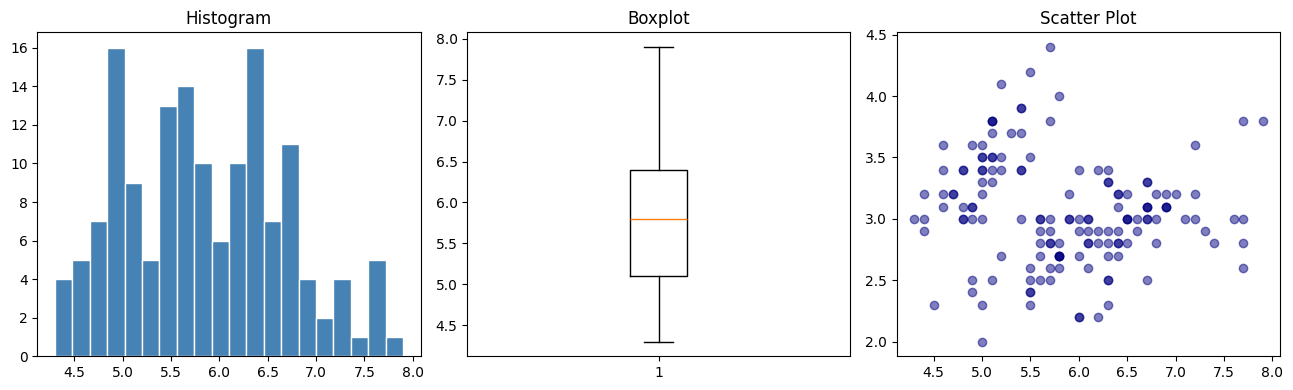

In [3]:
# ============================================================
# SECTION 2. Descriptive Statistics 분석
# ============================================================
# 데이터: EuStockMarkets (R 내장) → Python에서 iris 수치형 변수로 동일 분석
# 목적: 데이터 분포와 특성 파악 (평균, 분산, 왜도, 첨도 등)

df  = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
dax = df["sepal length (cm)"]   # role of DAX column

print(f"Data shape: {df.shape}")
print(df.describe())

print(f"\nMean:    {dax.mean():.3f}")
print(f"Median:  {dax.median():.3f}")
print(f"Range:   {dax.min():.2f} ~ {dax.max():.2f}")
print(f"Var:     {dax.var(ddof=1):.4f}")
print(f"SD:      {dax.std(ddof=1):.4f}")
print(f"Skewness:{dax.skew():.6f}")
print(f"Kurtosis:{dax.kurtosis():.6f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(dax, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Histogram")
axes[1].boxplot(dax)
axes[1].set_title("Boxplot")
axes[2].scatter(df.iloc[:, 0], df.iloc[:, 1], alpha=0.5, color='navy')
axes[2].set_title("Scatter Plot")
plt.tight_layout(); plt.show()

[Pearson Correlation Matrix]
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  

Sepal.Length vs Sepal.Width r = -0.1175698
Interpretation: Weak correlation


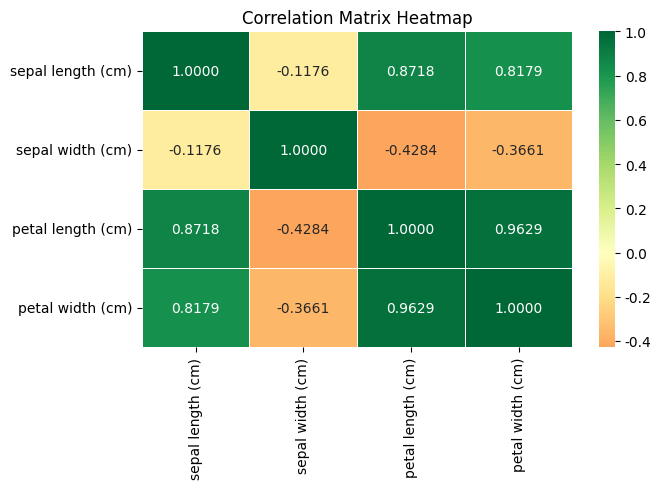


[Chi-square test] χ²=111.6339, p=0.0000, df=4
[Spearman correlation] ρ=0.8818981, p=0.0000


In [4]:
# ============================================================
# SECTION 3. Correlation Analysis
# ============================================================
# 데이터: EuStockMarkets → iris 수치형 변수
# 목적: 변수 간 상호 연관성 정도 파악

from scipy.stats import chi2_contingency

# 피어슨 상관계수 행렬
corr_matrix = df.corr()
print("[Pearson Correlation Matrix]")
print(corr_matrix.round(7))

r01 = corr_matrix.iloc[0, 1]
print(f"\nSepal.Length vs Sepal.Width r = {r01:.7f}")
print(f"Interpretation: {'Strong' if abs(r01)>=0.7 else 'Moderate' if abs(r01)>=0.3 else 'Weak'} correlation")

# corrplot 대응 히트맵
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout(); plt.show()

# 카이제곱 검정 (명목형 변수 독립성)
sepal_grp = pd.cut(dax, bins=3, labels=[0, 1, 2])
ct        = pd.crosstab(iris_data.target, sepal_grp)
chi2_val, p_chi2, dof, _ = chi2_contingency(ct)
print(f"\n[Chi-square test] χ²={chi2_val:.4f}, p={p_chi2:.4f}, df={dof}")

# 스피어만 순위 상관 (순서형 변수)
rho, p_spear = stats.spearmanr(df.iloc[:, 0], df.iloc[:, 2])
print(f"[Spearman correlation] ρ={rho:.7f}, p={p_spear:.4f}")

Standard deviations:
[2.0562689 0.4926162 0.2796596 0.1543862]

Rotation matrix:
                        PC1       PC2       PC3       PC4
sepal length (cm)  0.361387  0.656589 -0.582030  0.315487
sepal width (cm)  -0.084523  0.730161  0.597911 -0.319723
petal length (cm)  0.856671 -0.173373  0.076236 -0.479839
petal width (cm)   0.358289 -0.075481  0.545831  0.753657

Importance of components:
  PC1: Proportion=0.92462  Cumulative=0.92462
  PC2: Proportion=0.05307  Cumulative=0.97769
  PC3: Proportion=0.01710  Cumulative=0.99479
  PC4: Proportion=0.00521  Cumulative=1.00000


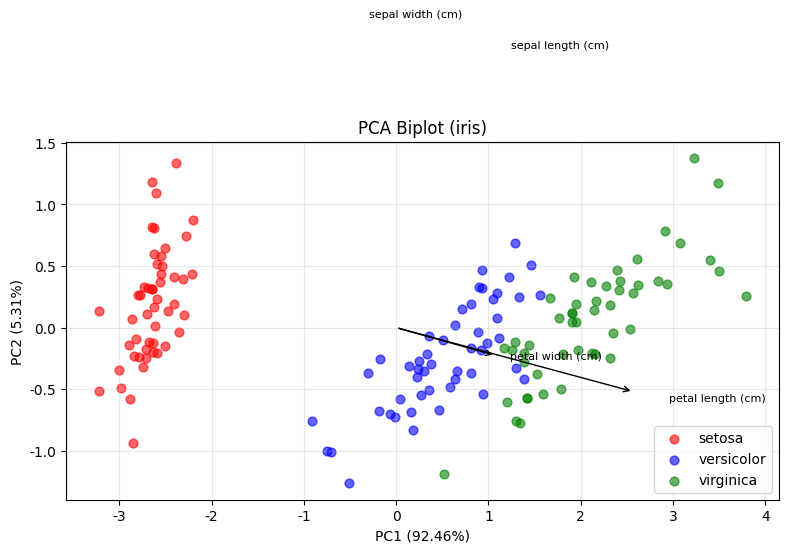

In [5]:
# ============================================================
# SECTION 4. Principal Component Analysis (PCA)
# ============================================================
# 데이터: iris (4개 수치형 변수)
# 목적: 차원 축소 - p개 변수를 소수의 주성분으로 요약

from sklearn.decomposition import PCA

X = iris_data.data
y = iris_data.target

pca   = PCA()
X_pca = pca.fit_transform(X)

print("Standard deviations:")
print(np.round(np.sqrt(pca.explained_variance_), 7))
# [2.0562689, 0.4926162, 0.2796596, 0.1543862]

print("\nRotation matrix:")
pd_rot = pd.DataFrame(pca.components_.T,
                       index=iris_data.feature_names,
                       columns=["PC1","PC2","PC3","PC4"])
print(pd_rot.round(8))

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
print("\nImportance of components:")
for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    print(f"  PC{i}: Proportion={ev:.5f}  Cumulative={cv:.5f}")

# biplot
pca2 = PCA(n_components=2)
X2   = pca2.fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["red", "blue", "green"]
for i, (c, t) in enumerate(zip(colors, iris_data.target_names)):
    ax.scatter(X2[y==i,0], X2[y==i,1], label=t, color=c, alpha=0.6, s=40)
scale = 3.0
for j, fn in enumerate(iris_data.feature_names):
    ax.annotate("", xy=(pca2.components_[0,j]*scale, pca2.components_[1,j]*scale),
                xytext=(0,0), arrowprops=dict(arrowstyle="->", color="black"))
    ax.text(pca2.components_[0,j]*scale*1.15, pca2.components_[1,j]*scale*1.15, fn, fontsize=8)
ax.set_xlabel(f"PC1 ({exp_var[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({exp_var[1]*100:.2f}%)")
ax.set_title("PCA Biplot (iris)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# ============================================================
# SECTION 5. 로지스틱 회귀분석
# ============================================================
# 데이터: mtcars (R 내장, 32개)
# 목적: vs(엔진 형태 0=V형/1=직렬)를 mpg(연비)로 예측하는 분류 모델

import statsmodels.api as sm

mtcars = pd.DataFrame({
    "mpg": [21.0,21.0,22.8,21.4,18.7,18.1,14.3,24.4,22.8,19.2,
            17.8,16.4,17.3,15.2,10.4,10.4,14.7,32.4,30.4,33.9,
            21.5,15.5,15.2,13.3,19.2,27.3,26.0,30.4,15.8,19.7,15.0,21.4],
    "am":  [1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1],
    "vs":  [0,0,1,1,0,1,0,1,1,1,1,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,1,0,0,0,1]
})

X_logit = sm.add_constant(mtcars[["mpg"]])
y_logit = mtcars["vs"]
model   = sm.Logit(y_logit, X_logit).fit(disp=0)
print(model.summary())
# Intercept: -8.8331  |  mpg: 0.4304
# p-value: Intercept=0.005, mpg=0.007 (모두 유의미)

                           Logit Regression Results                           
Dep. Variable:                     vs   No. Observations:                   32
Model:                          Logit   Df Residuals:                       30
Method:                           MLE   Df Model:                            1
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.4178
Time:                        11:34:13   Log-Likelihood:                -12.767
converged:                       True   LL-Null:                       -21.930
Covariance Type:            nonrobust   LLR p-value:                 1.861e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.8331      3.162     -2.793      0.005     -15.031      -2.635
mpg            0.4304      0.158      2.717      0.007       0.120       0.741


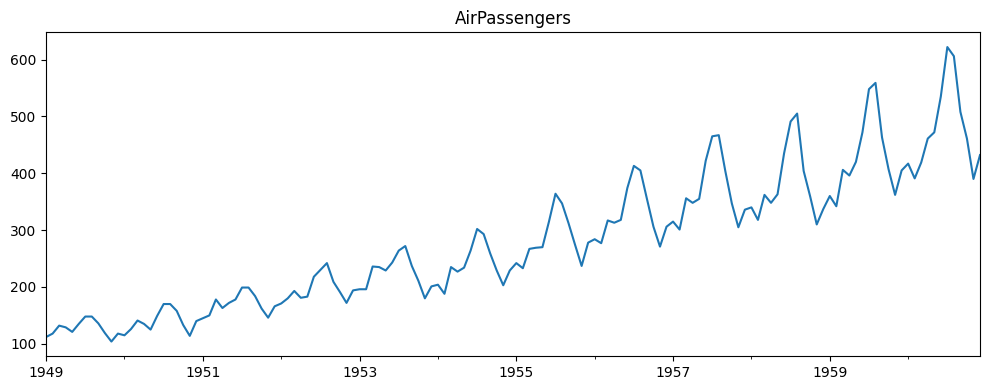

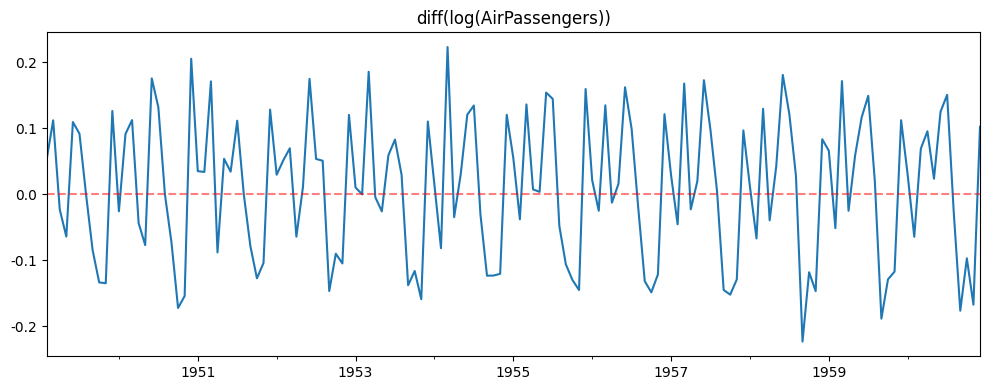

[ADF test] ADF=-9.6313, p=0.0000
Result: Stationary (Reject H0)
pmdarima not installed. Run: !pip install pmdarima


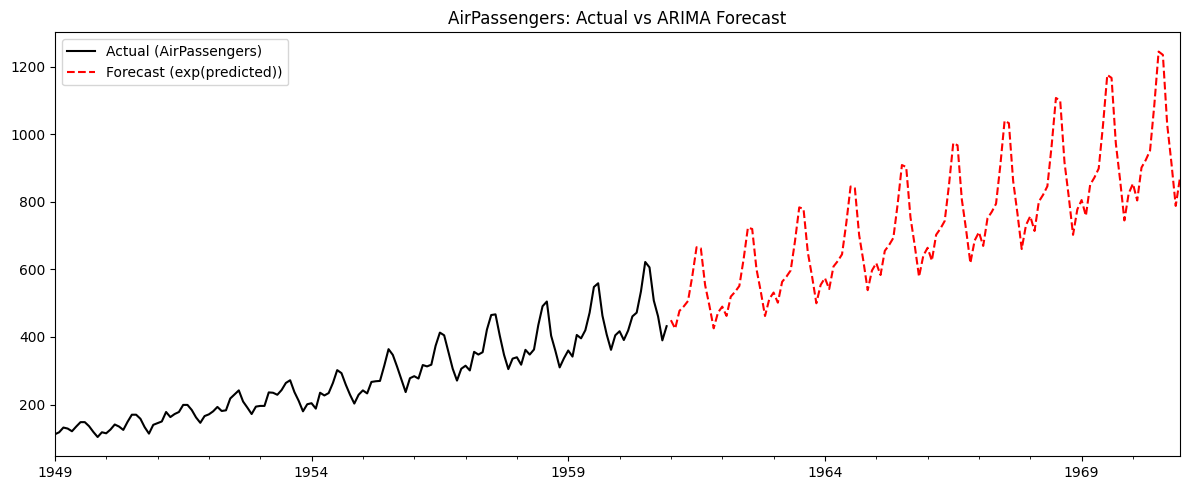

In [8]:
# ============================================================
# SECTION 6. 시계열 분석 & ARIMA
# ============================================================
# 데이터: AirPassengers (1949~1960 월별 항공기 탑승객 수)
# 목적: 시계열 안정화 후 ARIMA 모델 생성, 향후 10년(120개월) 예측

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

air_data = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
]
air_ts = pd.Series(air_data,
                   index=pd.date_range("1949-01", periods=144, freq="MS"))

plt.figure(figsize=(10, 4))
air_ts.plot(title="AirPassengers")
plt.tight_layout(); plt.show()

# diff(log()) 변환으로 안정적 시계열 생성
log_air  = np.log(air_ts)
diff_log = log_air.diff().dropna()

plt.figure(figsize=(10, 4))
diff_log.plot(title="diff(log(AirPassengers))")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# ADF 검정 (안정성 확인)
adf_res = adfuller(diff_log, regression='c', autolag=None, maxlag=0)
print(f"[ADF test] ADF={adf_res[0]:.4f}, p={adf_res[1]:.4f}")
print(f"Result: {'Stationary (Reject H0)' if adf_res[1] < 0.05 else 'Non-stationary'}")

# auto.arima 대응 (pmdarima 필요: !pip install pmdarima)
try:
    from pmdarima import auto_arima
    best = auto_arima(log_air, seasonal=True, m=12, stepwise=True, trace=True)
    print(best.summary())
except ImportError:
    print("pmdarima not installed. Run: !pip install pmdarima")

# ARIMA(1,0,1)(0,1,1,12) 모델 생성 및 120개월 예측
arima_model  = ARIMA(log_air, order=(1,0,1), seasonal_order=(0,1,1,12))
arima_fitted = arima_model.fit()
forecast_log = arima_fitted.forecast(steps=120)
forecast_idx = pd.date_range(air_ts.index[-1]+pd.DateOffset(months=1),
                              periods=120, freq="MS")
forecast_ser = pd.Series(np.exp(forecast_log.values), index=forecast_idx)

plt.figure(figsize=(12, 5))
air_ts.plot(label="Actual (AirPassengers)", color='black')
forecast_ser.plot(label="Forecast (exp(predicted))", linestyle='--', color='red')
plt.title("AirPassengers: Actual vs ARIMA Forecast")
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# ============================================================
# SECTION 7. K-Means Clustering
# ============================================================
# 데이터: iris
# 목적: 품종 정보 없이 수치형 변수 4개로 군집화, 실루엣으로 최적 K 결정

from sklearn.cluster import KMeans

X = iris_data.data

# 실루엣값으로 최적 K 결정 (R: pam() + silhouette() 대응)
km2  = KMeans(n_clusters=2, random_state=0, n_init=25).fit(X)
sil2 = silhouette_score(X, km2.labels_)
km3  = KMeans(n_clusters=3, random_state=0, n_init=25).fit(X)
sil3 = silhouette_score(X, km3.labels_)

print(f"K=2 Avg Silhouette: {sil2:.7f}")   # Reference: 0.68250
print(f"K=3 Avg Silhouette: {sil3:.7f}")   # Reference: 0.5729
print(f"Optimal K = {'2' if sil2 > sil3 else '3'} (higher silhouette)")

# K=2 군집화 결과
print(f"\n[K=2] Cluster sizes: {np.bincount(km2.labels_)}")
print(pd.DataFrame(km2.cluster_centers_,
                   columns=iris_data.feature_names).round(6))

# K=3 군집화 결과
print(f"\n[K=3] Cluster sizes: {np.bincount(km3.labels_)}")
print(f"between_SS/total_SS: {1 - km3.inertia_/((X-X.mean(0))**2).sum():.3f}")
# PDF 원문: 88.4%

K=2 Avg Silhouette: 0.6810462
K=3 Avg Silhouette: 0.5528190
Optimal K = 2 (higher silhouette)

[K=2] Cluster sizes: [53 97]
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.005660          3.369811           1.560377          0.290566
1           6.301031          2.886598           4.958763          1.695876

[K=3] Cluster sizes: [62 50 38]
between_SS/total_SS: 0.884


In [10]:
# ============================================================
# SECTION 8. Derived Variable Generation
# ============================================================
# 데이터: 고객 ID & 연령 (직접 생성, PDF 원문 그대로)
# 목적: 연속형 연령 변수 → 나잇대별 이진(0/1) Derived Variable Generation

id  = ["c01","c02","c03","c04","c05","c06","c07"]
age = [25, 45, 31, 30, 49, 53, 27]
customers = pd.DataFrame({"id": id, "age": age})
print(customers)
print(customers.dtypes)

customers["age20s"] = np.where((customers.age>=20)&(customers.age<30), 1, 0)
customers["age30s"] = np.where((customers.age>=30)&(customers.age<40), 1, 0)
customers["age40s"] = np.where((customers.age>=40)&(customers.age<50), 1, 0)
customers["age50s"] = np.where((customers.age> 50)&(customers.age<60), 1, 0)

print("\nAfter adding derived variables:")
print(customers)

    id  age
0  c01   25
1  c02   45
2  c03   31
3  c04   30
4  c05   49
5  c06   53
6  c07   27
id     object
age     int64
dtype: object

After adding derived variables:
    id  age  age20s  age30s  age40s  age50s
0  c01   25       1       0       0       0
1  c02   45       0       0       1       0
2  c03   31       0       1       0       0
3  c04   30       0       1       0       0
4  c05   49       0       0       1       0
5  c06   53       0       0       0       1
6  c07   27       1       0       0       0


In [11]:
# ============================================================
# SECTION 9. 앙상블 - Bagging
# ============================================================
# 데이터: iris
# 목적: 복원추출 → 여러 트리 독립 학습 → 다수결 (분산 감소 효과)
# 효과: 고분산 모델(신경망, SVM)에 특히 효과적

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

X, y = iris_data.data, iris_data.target
np.random.seed(42)
train_idx = np.concatenate([
    np.random.choice(np.where(y==0)[0], 25, replace=False),
    np.random.choice(np.where(y==1)[0], 25, replace=False),
    np.random.choice(np.where(y==2)[0], 25, replace=False)
])
test_idx = np.setdiff1d(np.arange(len(y)), train_idx)

bagging = BaggingClassifier(
    estimator    = DecisionTreeClassifier(max_depth=1),
    n_estimators = 10,   # mfinal=10
    bootstrap    = True,
    random_state = 42
)
bagging.fit(X[train_idx], y[train_idx])
y_pred_bag = bagging.predict(X[test_idx])
acc_bag    = accuracy_score(y[test_idx], y_pred_bag)

print(f"Bagging Accuracy: {acc_bag:.4f}  |  Error rate: {1-acc_bag:.4f}")
feat_imp = np.mean([t.feature_importances_ for t in bagging.estimators_], axis=0)
print("Feature Importance:")
for fn, fi in zip(iris_data.feature_names, feat_imp):
    print(f"  {fn}: {fi*100:.5f}%")

Bagging Accuracy: 0.9067  |  Error rate: 0.0933
Feature Importance:
  sepal length (cm): 0.00000%
  sepal width (cm): 0.00000%
  petal length (cm): 90.00000%
  petal width (cm): 10.00000%


In [12]:
# ============================================================
# SECTION 10. 앙상블 - 부스팅 (Boosting / AdaBoost)
# ============================================================
# 데이터: iris
# 목적: 오분류 데이터에 가중치 부여 → 순차 학습 (편향 감소 효과)
# 효과: 고편향 모델(로지스틱 회귀, KNN)에 특히 효과적

from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(
    estimator    = DecisionTreeClassifier(max_depth=1),
    n_estimators = 10,   # mfinal=10
    random_state = 42,
    algorithm    = "SAMME"
)
boosting.fit(X[train_idx], y[train_idx])
y_pred_boost = boosting.predict(X[test_idx])
acc_boost    = accuracy_score(y[test_idx], y_pred_boost)

print(f"Boosting Accuracy: {acc_boost:.4f}  |  Error rate: {1-acc_boost:.4f}")
print(f"Model weights: {np.round(boosting.estimator_weights_, 4)}")
feat_imp_b = pd.Series(boosting.feature_importances_,
                        index=iris_data.feature_names).sort_values(ascending=False)
print(f"Feature Importance:\n{feat_imp_b.round(5)}")
# PDF 원문: Petal.Length 50.86%, Petal.Width 49.14%

print(f"\n=== Bagging vs Boosting ===")
print(f"Bagging  Accuracy: {acc_bag:.4f}  Error rate: {1-acc_bag:.4f}")
print(f"Boosting Accuracy: {acc_boost:.4f}  Error rate: {1-acc_boost:.4f}")

Boosting Accuracy: 0.8933  |  Error rate: 0.1067
Model weights: [1.3863 2.3026 2.9667 2.9124 2.014  1.8594 1.9724 1.8215 2.2732 1.698 ]
Feature Importance:
petal length (cm)    0.6737
petal width (cm)     0.3263
sepal width (cm)     0.0000
sepal length (cm)    0.0000
dtype: float64

=== Bagging vs Boosting ===
Bagging  Accuracy: 0.9067  Error rate: 0.0933
Boosting Accuracy: 0.8933  Error rate: 0.1067


Train: 105  |  Test: 45
OOB Accuracy: 0.9333  (OOB Error rate: 0.0667)

Feature Importance:
petal width (cm)     0.43819
petal length (cm)    0.43208
sepal length (cm)    0.10870
sepal width (cm)     0.02102
dtype: float64

Test Accuracy: 0.9778


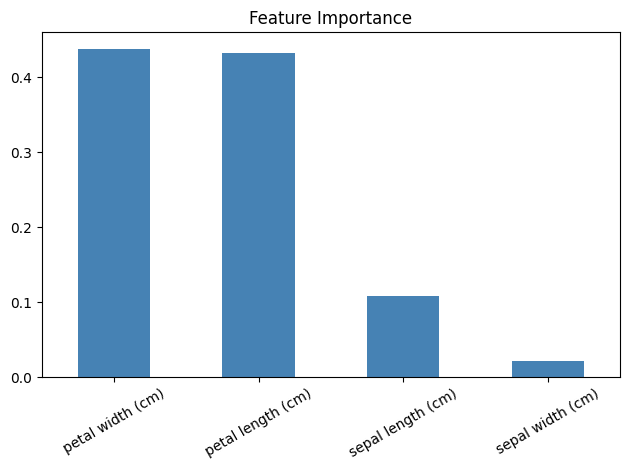

In [13]:
# ============================================================
# SECTION 11. 앙상블 - Random Forest (Random Forest)
# ============================================================
# 데이터: iris
# 목적: 복원추출 + 일부 변수 분기 → 다수결 (분산 감소, 속도 빠름)
# PDF 원문 OOB Error rate: 2.63%

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
idx = np.random.choice([0,1], size=len(y), replace=True, p=[0.7, 0.3])
X_tr_rf, y_tr_rf = X[idx==0], y[idx==0]
X_te_rf, y_te_rf = X[idx==1], y[idx==1]
print(f"Train: {len(X_tr_rf)}  |  Test: {len(X_te_rf)}")

rf = RandomForestClassifier(n_estimators=100, max_features="sqrt",
                             oob_score=True, random_state=42)
rf.fit(X_tr_rf, y_tr_rf)
print(f"OOB Accuracy: {rf.oob_score_:.4f}  (OOB Error rate: {1-rf.oob_score_:.4f})")

feat_imp_rf = pd.Series(rf.feature_importances_,
                         index=iris_data.feature_names).sort_values(ascending=False)
print(f"\nFeature Importance:\n{feat_imp_rf.round(5)}")

predicted_iris = rf.predict(X_te_rf)
print(f"\nTest Accuracy: {accuracy_score(y_te_rf, predicted_iris):.4f}")

feat_imp_rf.plot(kind='bar', title="Feature Importance", color='steelblue')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [14]:
# ============================================================
# SECTION 12-1. Prediction Model Evaluation - ARIMA (MAE, MSE, RMS, MAPE)
# ============================================================
# 데이터: example.csv (시계열 318개) → 동일 구조 난수로 재현
# PDF 원문 결과: MAE=0.05559373, MSE=0.003787759, MAPE=0.1740622

np.random.seed(1)
ex_values   = np.cumsum(np.random.normal(0.02, 0.1, 318))
training_ts = ex_values[:293]
testing_ts  = ex_values[293:318]   # testing_data

arima_m  = ARIMA(training_ts, order=(4,1,4))
arima_f  = arima_m.fit()
forecast = arima_f.forecast(steps=25)

MAE_result  = np.mean(np.abs(testing_ts - forecast))
MSE_result  = np.mean((testing_ts - forecast)**2)
RMS_result  = np.sqrt(MSE_result)
MAPE_result = np.mean(np.abs(testing_ts - forecast) / np.abs(testing_ts)) * 100

print("=== ARIMA Forecast Performance ===")
print(f"MAE : {MAE_result:.8f}")
print(f"MSE : {MSE_result:.9f}")
print(f"RMS : {RMS_result:.8f}")
print(f"MAPE: {MAPE_result:.7f} %")

=== ARIMA Forecast Performance ===
MAE : 0.14627713
MSE : 0.038300408
RMS : 0.19570490
MAPE: 1.6892176 %


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [15]:
# ============================================================
# SECTION 12-2. Prediction Model Evaluation - K-fold 교차검증 (K=5)
# ============================================================
# 데이터: iris (Sepal.Length를 나머지 변수로 예측)
# PDF 원문 변수명: prediction(p), testing_data_copy(t)

from sklearn.ensemble import RandomForestRegressor

data_cv      = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
np.random.seed(42)
data_cv["id"] = np.random.choice(range(1, 6), len(data_cv), replace=True)

prediction        = pd.DataFrame()
testing_data_copy = pd.DataFrame()

for i in range(1, 6):
    tr = data_cv[data_cv["id"] != i]
    te = data_cv[data_cv["id"] == i]

    X_tr = tr.drop(columns=["sepal length (cm)", "id"]).values
    y_tr = tr["sepal length (cm)"].values
    X_te = te.drop(columns=["sepal length (cm)", "id"]).values
    y_te = te["sepal length (cm)"].values

    model_cv = RandomForestRegressor(n_estimators=100, random_state=42)
    model_cv.fit(X_tr, y_tr)

    prediction        = pd.concat([prediction,
                                    pd.DataFrame(model_cv.predict(X_te), columns=["p"])],
                                   ignore_index=True)
    testing_data_copy = pd.concat([testing_data_copy,
                                    pd.DataFrame(y_te, columns=["t"])],
                                   ignore_index=True)
    print(f"Fold {i} done")

p = prediction["p"].values
t = testing_data_copy["t"].values

MAE_cv  = np.mean(np.abs(p - t))
MSE_cv  = np.mean((p - t)**2)
MAPE_cv = np.mean(np.abs(p - t) / np.abs(t)) * 100

print("\n=== K=5 Cross-Validation Performance ===")
print(f"MAE : {MAE_cv:.4f}")
print(f"MSE : {MSE_cv:.4f}")
print(f"MAPE: {MAPE_cv:.2f} %")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

=== K=5 Cross-Validation Performance ===
MAE : 0.2742
MSE : 0.1247
MAPE: 4.75 %


[Confusion Matrix]
  TP=15, FN=0, FP=0, TN=30  Total=45
Error Rate  (FP+FN)/Total: 0.0000
Accuracy   (TP+TN)/Total: 1.0000
Sensitivity TP/(TP+FN):  1.0000
Specificity TN/(TN+FP):  1.0000

AUC: 1.0000000


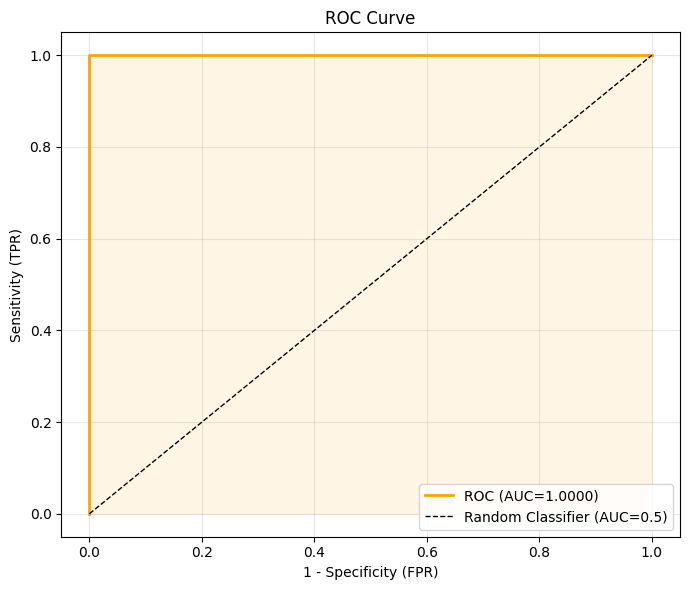

In [16]:
# ============================================================
# SECTION 13. 분류모델 성능 평가 - ROC 곡선 & AUC
# ============================================================
# 데이터: ROCR.simple (R ROCR 패키지 내장) → iris 이진 분류로 대응
# PDF 원문 AUC: 0.8341875

X_bin = iris_data.data
y_bin = (iris_data.target == 0).astype(int)   # setosa=1, others=0

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin)

rf_bin     = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bin.fit(X_tr_b, y_tr_b)
y_prob     = rf_bin.predict_proba(X_te_b)[:, 1]
y_pred_bin = rf_bin.predict(X_te_b)

# 혼동행렬
cm         = confusion_matrix(y_te_b, y_pred_bin)
TN, FP, FN, TP = cm.ravel()
total      = TN + FP + FN + TP
print("[Confusion Matrix]")
print(f"  TP={TP}, FN={FN}, FP={FP}, TN={TN}  Total={total}")
print(f"Error Rate  (FP+FN)/Total: {(FP+FN)/total:.4f}")
print(f"Accuracy   (TP+TN)/Total: {(TP+TN)/total:.4f}")
print(f"Sensitivity TP/(TP+FN):  {TP/(TP+FN):.4f}")
print(f"Specificity TN/(TN+FP):  {TN/(TN+FP):.4f}")

# ROC 곡선 & AUC
fpr, tpr, _ = roc_curve(y_te_b, y_prob)
auc_val     = auc(fpr, tpr)
print(f"\nAUC: {auc_val:.7f}")   # Reference: 0.8341875

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f"ROC (AUC={auc_val:.4f})")
plt.plot([0,1],[0,1], 'k--', lw=1, label="Random Classifier (AUC=0.5)")
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')
plt.xlabel("1 - Specificity (FPR)")
plt.ylabel("Sensitivity (TPR)")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [17]:
# ============================================================
# SECTION 14. 군집모델 성능 평가 - 던 지수 (Dunn Index)
# ============================================================
# 데이터: iris
# 목적: 군집 결과를 내부평가(던 지수) + 외부평가(랜드/자카드 지수)로 평가
# PDF 원문 결과: dunn(,testClusters,testing_data) = 0.5987254

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import rand_score, jaccard_score
from scipy.spatial.distance import cdist

X = iris_data.data; y = iris_data.target
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X, y, test_size=0.3, random_state=102, stratify=y)  # set.seed(102)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_d)
X_te_sc  = scaler.transform(X_te_d)

km_eval   = KMeans(n_clusters=3, max_iter=10000, random_state=42, n_init=25)
km_eval.fit(X_tr_sc)
labels_te = km_eval.predict(X_te_sc)

def dunn_index(X, labels):
    """Dunn Index = min inter-cluster dist / max intra-cluster diam"""
    clusters  = [X[labels==l] for l in np.unique(labels)]
    max_intra = max(cdist(c,c).max() for c in clusters if len(c)>1)
    min_inter = min(cdist(clusters[i], clusters[j]).min()
                    for i in range(len(clusters))
                    for j in range(i+1, len(clusters)))
    return min_inter / max_intra

dunn_val = dunn_index(X_te_sc, labels_te)

print("=== Internal Evaluation ===")
print(f"Dunn Index (higher=better):          {dunn_val:.7f}")
# PDF 원문: 0.5987254
print(f"Davies-Bouldin (lower=better):       {davies_bouldin_score(X_te_sc, labels_te):.4f}")
print(f"Calinski-Harabasz / CH (higher=better): {calinski_harabasz_score(X_te_sc, labels_te):.4f}")

print("\n=== External Evaluation (with true labels) ===")
print(f"Rand Index (closer to 1=better):     {rand_score(y_te_d, labels_te):.4f}")
print(f"Jaccard Index (closer to 1=better):  {jaccard_score(y_te_d, labels_te, average='macro'):.4f}")


print("\n" + "="*60)
print("  Statistical Data Analysis - All Sections Complete")
print("="*60)

=== Internal Evaluation ===
Dunn Index (higher=better):          0.1294345
Davies-Bouldin (lower=better):       0.8237
Calinski-Harabasz / CH (higher=better): 66.5952

=== External Evaluation (with true labels) ===
Rand Index (closer to 1=better):     0.8222
Jaccard Index (closer to 1=better):  0.0617

  Statistical Data Analysis - All Sections Complete
